In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                    AUTOFILLGRAPH v2 — 5 CODE BLOCKS              ║
# ║                                                                  ║
# ║  Block 1: System + ALL Definitions (classes, functions)          ║
# ║  Block 2: Learn Identity + Contact Layer → Visualize Graph       ║
# ║  Block 3: Learn Academic Layer + Temporal Update → History Plot  ║
# ║  Block 4: Autofill Job Application + University Admission        ║
# ║  Block 5: Stress Test (Inference/Missing/Generative/Privacy/     ║
# ║           Cross-Domain)                                          ║
# ╚══════════════════════════════════════════════════════════════════╝


###############################################################################
# ██████╗ ██╗      ██████╗  ██████╗██╗  ██╗     ██╗
# ██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝    ███║
# ██████╔╝██║     ██║   ██║██║     █████╔╝     ╚██║
# ██╔══██╗██║     ██║   ██║██║     ██╔═██╗      ██║
# ██████╔╝███████╗╚██████╔╝╚██████╗██║  ██╗     ██║
# ╚═════╝ ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝     ╚═╝
# SYSTEM SETUP — All classes, functions, resolvers defined here.
# Blocks 2–5 only CALL these with data.
###############################################################################

# @title 1. System Setup: Typed Temporal Knowledge Graph + All Functions

# ── Install dependencies ──
# Pin mistralai to latest stable. If already installed, pip will skip.
!pip install -q "mistralai>=1.0" networkx matplotlib

import json
import re
import time
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timezone
from enum import Enum
from dataclasses import dataclass, field, asdict
from typing import Optional, Dict, List, Any, Tuple
from collections import Counter

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIX #1: Robust Mistral import — works for BOTH v1.x and v2.x
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
# The root cause of the ImportError:
#   v1.x:  `from mistralai import Mistral`            ← works
#   v2.x:  `from mistralai.client import Mistral`     ← works
#   v2.x:  `from mistralai import Mistral`             ← FAILS
#
# The v2.x package uses a namespace __init__.py that does NOT
# re-export the Mistral class at the top level. Colab's pip
# installs v2.x by default. We try both import paths.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Mistral = None
_import_errors = []

# Attempt 1: v2.x path (most common on fresh Colab installs)
try:
    from mistralai.client import Mistral as _M
    Mistral = _M
except ImportError as e:
    _import_errors.append(f"mistralai.client: {e}")

# Attempt 2: v1.x path
if Mistral is None:
    try:
        from mistralai import Mistral as _M
        Mistral = _M
    except ImportError as e:
        _import_errors.append(f"mistralai: {e}")

# Attempt 3: v0.x legacy (MistralClient)
if Mistral is None:
    try:
        from mistralai.client import MistralClient as Mistral
        print("⚠️  Using legacy MistralClient (v0.x). "
              "Consider: pip install --upgrade mistralai")
    except ImportError as e:
        _import_errors.append(f"mistralai.client.MistralClient: {e}")

if Mistral is None:
    raise ImportError(
        "Could not import Mistral from any known path.\n"
        "Tried:\n  " + "\n  ".join(_import_errors) + "\n"
        "Fix: restart runtime, then run:\n"
        "  !pip install --upgrade mistralai"
    )

print(f"✅ Mistral SDK loaded: {Mistral.__module__}.{Mistral.__name__}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIX #2: Graceful API key — works in Colab AND local/CI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import os
API_KEY = None
try:
    from google.colab import userdata
    API_KEY = userdata.get("api-key")
except Exception:
    pass

if not API_KEY:
    API_KEY = (os.environ.get("MISTRAL_API_KEY")
               or os.environ.get("api-key")
               or os.environ.get("API_KEY"))

if not API_KEY:
    raise RuntimeError(
        "No Mistral API key found.\n"
        "  • In Colab: add a secret named 'api-key' via the 🔑 sidebar.\n"
        "  • Locally : export MISTRAL_API_KEY=sk-..."
    )

# ━━━ API Connection ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

client = Mistral(api_key=API_KEY)
MODEL_ID = "mistral-small-latest"

test = client.chat.complete(
    model=MODEL_ID,
    messages=[{"role": "user", "content": "Reply with: CONNECTED"}]
)
print(f"✅ Mistral: {test.choices[0].message.content.strip()}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TYPED SCHEMA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class EntityType(str, Enum):
    PERSON       = "Person"
    ORGANIZATION = "Organization"
    LOCATION     = "Location"
    CREDENTIAL   = "Credential"
    ROLE         = "Role"
    INTEREST     = "Interest"

class Sensitivity(str, Enum):
    PUBLIC     = "public"       # Can be sent to LLM API
    RESTRICTED = "restricted"   # Local-only, needs consent for API
    ENCRYPTED  = "encrypted"    # Never leaves device

class FillStatus(str, Enum):
    FILLED         = "filled"
    INFERRED       = "inferred"
    GENERATED      = "generated"
    UNKNOWN        = "unknown"
    NOT_APPLICABLE = "not_applicable"
    CONFLICT       = "conflict"

LAYER_DEFINITIONS = {
    "identity": {
        "sensitivity": Sensitivity.PUBLIC,
        "properties": ["full_name", "display_name", "aliases"]
    },
    "contact": {
        "sensitivity": Sensitivity.PUBLIC,
        "properties": ["email", "phone", "address", "city", "state",
                        "region", "zip_code", "country",
                        "portfolio_url", "linkedin"]
    },
    "academic": {
        "sensitivity": Sensitivity.PUBLIC,
        "properties": ["university", "department", "degree", "gpa",
                        "advisor", "research_interests", "graduation_year"]
    },
    "professional": {
        "sensitivity": Sensitivity.PUBLIC,
        "properties": ["employer", "job_title", "skills",
                        "years_experience", "work_email"]
    },
    "medical": {
        "sensitivity": Sensitivity.RESTRICTED,
        "properties": ["conditions", "medications", "insurance_id",
                        "blood_type", "allergies", "primary_care"]
    },
    "financial": {
        "sensitivity": Sensitivity.RESTRICTED,
        "properties": ["tax_id", "ssn", "bank_name",
                        "annual_income", "credit_score"]
    },
    "legal": {
        "sensitivity": Sensitivity.ENCRYPTED,
        "properties": ["passport_number", "visa_status",
                        "citizenship", "drivers_license"]
    }
}


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DATA CLASSES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@dataclass
class AttributeValue:
    """A single fact with full temporal + provenance metadata."""
    value: str
    value_type: str
    created_at: str
    valid_from: str
    valid_until: Optional[str]   # None = currently valid
    source: str
    confidence: float
    verified: bool
    layer: str
    sensitivity: str

    def is_current(self) -> bool:
        return self.valid_until is None

@dataclass
class InferredFact:
    """A derived fact tracked separately from stored facts."""
    field: str
    value: str
    rule: str
    source_facts: List[str]
    confidence: float
    generated_at: str

@dataclass
class FillResult:
    """Result of filling a single form field."""
    field_label: str
    value: Optional[str]
    status: FillStatus
    confidence: float
    evidence: List[str]
    inference_chain: Optional[str] = None


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIX #3: Robust JSON parser for LLM output
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def _safe_parse_json(text: str) -> dict:
    """
    Parse JSON robustly from LLM responses.
    Handles: markdown fences, leading prose, trailing junk, trailing commas.
    """
    if not text or not text.strip():
        return {}
    s = text.strip()

    # Strip markdown code fences: ```json ... ``` or ``` ... ```
    fence_match = re.search(r'```(?:json)?\s*\n?(.*?)```', s, re.DOTALL)
    if fence_match:
        s = fence_match.group(1).strip()

    # If still not starting with '{', find the first '{'
    if not s.startswith('{'):
        idx = s.find('{')
        if idx != -1:
            s = s[idx:]
        else:
            return {}

    # Find the matching closing '}' via brace counting (string-aware)
    depth = 0
    end = -1
    in_string = False
    escape_next = False
    for i, ch in enumerate(s):
        if escape_next:
            escape_next = False
            continue
        if ch == '\\' and in_string:
            escape_next = True
            continue
        if ch == '"' and not escape_next:
            in_string = not in_string
            continue
        if in_string:
            continue
        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                end = i
                break
    if end != -1:
        s = s[:end + 1]

    try:
        return json.loads(s)
    except json.JSONDecodeError:
        # Fix trailing commas before } or ]
        s_fixed = re.sub(r',\s*([}\]])', r'\1', s)
        try:
            return json.loads(s_fixed)
        except json.JSONDecodeError:
            print(f"   ⚠️ JSON parse failed. Raw (first 300 chars): "
                  f"{text[:300]}")
            return {}


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DETERMINISTIC RESOLVERS — Lightweight, no API calls, GLOBAL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class DeterministicResolvers:
    """
    Resolvers for patterns that don't need an LLM.
    Intentionally minimal — NOT meant to be an exhaustive world database.
    The LLM handles everything these miss.
    """

    # Email domain → Org (seed set, grows via learn_mapping)
    EMAIL_DOMAIN_MAP = {
        # US
        "umd.edu": "University of Maryland",
        "umich.edu": "University of Michigan",
        "mit.edu": "MIT",
        "stanford.edu": "Stanford University",
        "berkeley.edu": "UC Berkeley",
        # Europe
        "ox.ac.uk": "University of Oxford",
        "cam.ac.uk": "University of Cambridge",
        "ethz.ch": "ETH Zurich",
        "tum.de": "TU Munich",
        # Asia
        "iitb.ac.in": "IIT Bombay",
        "iitm.ac.in": "IIT Madras",
        "nus.edu.sg": "NUS Singapore",
        "u-tokyo.ac.jp": "University of Tokyo",
        # Personal providers → no org
        "gmail.com": None, "outlook.com": None,
        "yahoo.com": None, "hotmail.com": None,
        "protonmail.com": None,
    }

    # Phone prefix → Country
    PHONE_COUNTRY_MAP = {
        "+1": "United States", "+44": "United Kingdom",
        "+91": "India", "+86": "China", "+81": "Japan",
        "+49": "Germany", "+33": "France", "+61": "Australia",
        "+65": "Singapore", "+82": "South Korea",
        "+55": "Brazil", "+7": "Russia", "+34": "Spain",
        "+39": "Italy", "+31": "Netherlands",
    }

    @classmethod
    def resolve_email_domain(cls, email: str) -> Optional[str]:
        domain = email.split("@")[-1].lower() if "@" in email else None
        return cls.EMAIL_DOMAIN_MAP.get(domain) if domain else None

    @classmethod
    def resolve_phone_country(cls, phone: str) -> Optional[str]:
        for code, country in sorted(cls.PHONE_COUNTRY_MAP.items(),
                                     key=lambda x: -len(x[0])):
            if phone.startswith(code):
                return country
        return None

    @classmethod
    def parse_address(cls, address: str) -> Dict[str, str]:
        """
        Extract city + postal code from address. Works globally:
        - "College Park, MD 20740"       → city=College Park, zip=20740
        - "Trivandrum, Kerala 695001"     → city=Trivandrum, region=Kerala, zip=695001
        - "London, SW1A 1AA"             → city=London, zip=SW1A 1AA
        - "Tokyo, Shibuya-ku 150-0002"   → city=Tokyo, zip=150-0002
        """
        parts = {}

        # Postal/ZIP: 5-6 digits (US/India/many), or alphanumeric (UK/Canada/Japan)
        zip_match = re.search(
            r'\b(\d{5,6}(?:-\d{4})?)\b'           # US/India: 20740, 695001
            r'|'
            r'\b([A-Z]{1,2}\d[A-Z\d]?\s*\d[A-Z]{2})\b'  # UK: SW1A 1AA
            r'|'
            r'\b(\d{3}-\d{4})\b',                  # Japan: 150-0002
            address, re.IGNORECASE)
        if zip_match:
            parts["zip_code"] = (zip_match.group(1) or
                                 zip_match.group(2) or
                                 zip_match.group(3))

        # Split on commas → first segment is typically city
        segments = [s.strip() for s in address.split(",")]
        if len(segments) >= 1:
            parts["city"] = segments[0]
        if len(segments) >= 2:
            # Second segment: region/state — strip postal codes out
            region = re.sub(r'\s*\d{3,6}(-\d{4})?\s*', '', segments[1]).strip()
            region = re.sub(r'\s*[A-Z]{1,2}\d[A-Z\d]?\s*\d[A-Z]{2}\s*', '',
                            region, flags=re.IGNORECASE).strip()
            if region:
                parts["region"] = region

        return parts

    @classmethod
    def detect_value_type(cls, key: str, value: str) -> str:
        k = key.lower()
        if "email" in k: return "email"
        if any(w in k for w in ["phone", "tel", "mobile"]): return "phone"
        if any(w in k for w in ["url", "portfolio", "github",
                                 "linkedin", "website"]): return "url"
        if any(w in k for w in ["gpa", "score", "income",
                                 "salary", "cgpa"]): return "numeric"
        if any(w in k for w in ["date", "dob", "year"]): return "date"
        if "address" in k: return "address"
        return "text"


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIELD LABEL MAPPER — Maps diverse form labels → canonical props
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class FieldMapper:

    SYNONYM_INDEX = {
        # Identity
        "full_name": ["full name", "candidate name", "applicant name",
                      "legal name", "your name", "name",
                      "student name", "patient name"],

        # Contact
        "email": ["email", "contact email", "e-mail", "email address",
                  "personal email", "primary email", "work email"],
        "phone": ["phone", "phone number", "contact number", "mobile",
                  "telephone", "cell", "mobile number"],
        "address": ["address", "current address", "mailing address",
                    "street address", "home address", "residence",
                    "current residency", "current mailing address"],
        "city": ["city", "town", "municipality"],
        "state": ["state", "province", "residency state",
                  "state/province"],
        "region": ["region", "prefecture", "district"],
        "zip_code": ["zip", "zip code", "postal code", "zipcode",
                     "pin code", "pincode", "postcode"],
        "country": ["country", "nation", "country of residence"],
        "portfolio_url": ["portfolio", "portfolio url", "website",
                          "personal website", "github", "github url"],
        "linkedin": ["linkedin", "linkedin url", "linkedin profile"],

        # Academic
        "university": ["university", "school", "institution", "college",
                       "university name", "alma mater",
                       "sponsoring institution"],
        "department": ["department", "dept", "academic department",
                       "field of study", "major"],
        "degree": ["degree", "degree program", "degree pursuing",
                   "qualification", "level of education"],
        "gpa": ["gpa", "grade point average", "cgpa", "cumulative gpa"],
        "advisor": ["advisor", "faculty advisor", "supervisor",
                    "thesis advisor", "research advisor"],
        "research_interests": ["research interests", "tech interests",
                               "areas of interest", "interests",
                               "specialization", "focus areas"],
        "graduation_year": ["graduation year", "expected graduation",
                            "year of graduation"],

        # Professional
        "employer": ["employer", "company", "organization",
                     "current employer"],
        "job_title": ["job title", "title", "position", "role",
                      "designation"],
        "skills": ["skills", "technical skills", "key skills",
                   "competencies"],
        "years_experience": ["years of experience", "experience",
                             "work experience"],

        # Legal
        "passport_number": ["passport number", "passport no", "passport",
                            "travel document number"],
        "citizenship": ["citizenship", "nationality",
                        "country of citizenship"],
        "visa_status": ["visa status", "immigration status", "visa type"],

        # Financial
        "ssn": ["ssn", "social security", "social security number"],
        "tax_id": ["tax id", "tin", "tax identification number",
                   "pan number"],
    }

    def __init__(self):
        self.reverse_index = {}
        for prop, synonyms in self.SYNONYM_INDEX.items():
            for syn in synonyms:
                self.reverse_index[syn.lower()] = prop

    def map_field(self, field_label: str) -> Optional[str]:
        normalized = field_label.lower().strip()
        # Direct match
        if normalized in self.reverse_index:
            return self.reverse_index[normalized]
        # Substring match
        for synonym, prop in self.reverse_index.items():
            if synonym in normalized or normalized in synonym:
                return prop
        return None

    def get_property_layer(self, prop: str) -> Optional[str]:
        for layer, defn in LAYER_DEFINITIONS.items():
            if prop in defn["properties"]:
                return layer
        return None

    def get_sensitivity(self, prop: str) -> Sensitivity:
        layer = self.get_property_layer(prop)
        if layer:
            return LAYER_DEFINITIONS[layer]["sensitivity"]
        return Sensitivity.PUBLIC

    def learn_mapping(self, field_label: str, prop: str):
        self.reverse_index[field_label.lower().strip()] = prop
        print(f"   📚 Learned: '{field_label}' → {prop}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CORE: AutoFillGraph CLASS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class AutoFillGraph:
    """
    Temporal Personal Knowledge Graph for intelligent form autofill.

    Key innovations over flat-store autofill:
    1. Typed schema — entities (graph nodes) vs attributes (node properties)
    2. Temporal validity — every fact has valid_from / valid_until
    3. Knowledge vs inference separation — derived facts in separate registry
    4. Subgraph retrieval — only relevant facts sent to LLM (privacy + cost)
    5. Sensitivity-gated routing — restricted/encrypted never reach API
    """

    # FIX #4: Single canonical ID for the user node, used everywhere.
    USER_ID = "user"

    def __init__(self, client, model):
        self.client = client
        self.model = model
        self.graph = nx.DiGraph()
        self.attributes: Dict[str, Dict[str, List[AttributeValue]]] = {}
        self.inferences: List[InferredFact] = []
        self.field_mapper = FieldMapper()
        self.resolvers = DeterministicResolvers()
        # FIX #7: Initialize ALL stat keys up front
        self.stats = {
            "facts_stored": 0,
            "facts_inferred": 0,
            "api_calls": 0,
            "local_fills": 0,
            "api_fills": 0,
        }
        # _ensure_entity("User") → lowercased to "user" as node ID
        self._ensure_entity("User", EntityType.PERSON)

    # ─── Helpers ──────────────────────────────────────────────

    @staticmethod
    def _to_id(name: str) -> str:
        """Canonical node-ID: lowercase, spaces → underscores."""
        return name.lower().replace(" ", "_")

    # ─── Entity Management ────────────────────────────────────

    def _ensure_entity(self, name: str, etype: EntityType,
                       aliases: List[str] = None) -> str:
        eid = self._to_id(name)
        if eid not in self.graph:
            self.graph.add_node(eid, display_name=name,
                                entity_type=etype.value,
                                aliases=aliases or [],
                                created_at=datetime.now(timezone.utc).isoformat())
            self.attributes[eid] = {}
        return eid

    def _add_relation(self, src: str, tgt: str, rel: str, ts: str = None):
        """Add directed edge. src/tgt can be display names or IDs."""
        ts = ts or datetime.now(timezone.utc).isoformat()
        sid = self._to_id(src)
        tid = self._to_id(tgt)
        if sid in self.graph and tid in self.graph:
            self.graph.add_edge(sid, tid, relationship=rel, created_at=ts)
        else:
            missing = []
            if sid not in self.graph: missing.append(sid)
            if tid not in self.graph: missing.append(tid)
            print(f"   ⚠️ Skipped edge {sid} → {tid}: "
                  f"missing node(s) {missing}")

    def _store_attribute(self, eid: str, prop: str, value: str,
                         value_type: str = "text",
                         source: str = "user_input",
                         confidence: float = 1.0):
        eid = self._to_id(eid)
        if eid not in self.attributes:
            self.attributes[eid] = {}

        layer = self.field_mapper.get_property_layer(prop) or "identity"
        sens = LAYER_DEFINITIONS.get(layer, {}).get(
            "sensitivity", Sensitivity.PUBLIC)
        now = datetime.now(timezone.utc).isoformat()

        # Temporal: expire old values of same property
        if prop in self.attributes[eid]:
            for old in self.attributes[eid][prop]:
                if old.is_current() and old.value != value:
                    old.valid_until = now
                    print(f"   ⏰ Expired: {prop}='{old.value}'")

        attr = AttributeValue(
            value=value, value_type=value_type, created_at=now,
            valid_from=now, valid_until=None, source=source,
            confidence=confidence, verified=False,
            layer=layer, sensitivity=sens.value)

        self.attributes[eid].setdefault(prop, []).append(attr)
        self.stats["facts_stored"] += 1

    def _store_inference(self, field: str, value: str, rule: str,
                         sources: List[str], confidence: float):
        self.inferences.append(InferredFact(
            field=field, value=value, rule=rule, source_facts=sources,
            confidence=confidence,
            generated_at=datetime.now(timezone.utc).isoformat()))
        self.stats["facts_inferred"] += 1

    # ─── Queries ──────────────────────────────────────────────

    def get_current_attributes(self, eid: str,
                               max_sens: Sensitivity = Sensitivity.PUBLIC
                               ) -> Dict[str, str]:
        eid = self._to_id(eid)
        levels = {Sensitivity.PUBLIC: 0, Sensitivity.RESTRICTED: 1,
                  Sensitivity.ENCRYPTED: 2}
        max_lvl = levels[max_sens]
        result = {}
        for prop, vals in self.attributes.get(eid, {}).items():
            for v in vals:
                if v.is_current() and levels[Sensitivity(v.sensitivity)] <= max_lvl:
                    result[prop] = v.value
        return result

    def get_attribute_history(self, eid: str, prop: str) -> List[AttributeValue]:
        eid = self._to_id(eid)
        return self.attributes.get(eid, {}).get(prop, [])

    # ─── Subgraph Retrieval ───────────────────────────────────

    def retrieve_subgraph(self, fields: List[str],
                          max_sens: Sensitivity = Sensitivity.PUBLIC) -> str:
        """Retrieve ONLY relevant facts for given fields (privacy + cost)."""
        needed = set()
        for f in fields:
            p = self.field_mapper.map_field(f)
            if p:
                needed.add(p)
            else:
                layer = self._guess_layer(f)
                if layer:
                    needed.update(LAYER_DEFINITIONS[layer]["properties"])

        lines = []
        attrs = self.get_current_attributes(self.USER_ID, max_sens)
        for p, v in attrs.items():
            if p in needed or not needed:
                lines.append(f"User.{p} = \"{v}\"")

        # 1-hop relations from User
        if self.USER_ID in self.graph:
            for _, tgt, d in self.graph.edges(self.USER_ID, data=True):
                tdata = self.graph.nodes.get(tgt, {})
                name = tdata.get("display_name", tgt)
                lines.append(f"User -[{d.get('relationship','')}]-> {name}")
                for p, v in self.get_current_attributes(tgt, max_sens).items():
                    lines.append(f"  {name}.{p} = \"{v}\"")

        # Include expired facts for "previous/former" queries
        for f in fields:
            if any(w in f.lower() for w in ["previous", "former", "old", "prior"]):
                for p, vals in self.attributes.get(self.USER_ID, {}).items():
                    for v in vals:
                        if not v.is_current():
                            end = v.valid_until[:10] if v.valid_until else "?"
                            lines.append(
                                f"User.{p} [EXPIRED] = \"{v.value}\" "
                                f"(valid {v.valid_from[:10]} to {end})")

        return "\n".join(lines)

    def _guess_layer(self, label: str) -> Optional[str]:
        l = label.lower()
        kw = {"identity": ["name","dob","birth"],
              "contact": ["email","phone","address","city","state","country"],
              "academic": ["university","degree","gpa","advisor","research",
                           "department","institution"],
              "professional": ["employer","company","job","title",
                               "experience","skills"],
              "medical": ["medical","health","insurance","medication","allergy"],
              "financial": ["income","tax","ssn","bank","salary"],
              "legal": ["passport","visa","citizenship","license"]}
        for layer, words in kw.items():
            if any(w in l for w in words):
                return layer
        return None

    # ─── LLM Interface ────────────────────────────────────────

    def _call_api(self, prompt: str, context: str = "") -> dict:
        """Robust API call with safe JSON parsing and graceful fallback."""
        self.stats["api_calls"] += 1
        try:
            msgs = []
            if context:
                msgs.append({"role": "system", "content": context})
            msgs.append({"role": "user", "content": prompt})
            resp = self.client.chat.complete(
                model=self.model, messages=msgs,
                temperature=0,
                response_format={"type": "json_object"})
            raw = resp.choices[0].message.content.strip()
            # FIX #3: Use robust parser instead of bare json.loads
            return _safe_parse_json(raw)
        except Exception as e:
            print(f"   ❌ API Error: {e}")
            return {}

    # ─── Visualization ────────────────────────────────────────

    def visualize(self, title="AutoFillGraph"):
        if self.graph.number_of_nodes() == 0:
            print("📭 Empty graph."); return

        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(self.graph, seed=42, k=1.5)

        type_colors = {
            "Person": "#FFB366", "Organization": "#66B2FF",
            "Location": "#66FF66", "Credential": "#FF6666",
            "Role": "#CC99FF",   "Interest": "#FFFF66"}

        colors = [type_colors.get(
            self.graph.nodes[n].get("entity_type", ""), "#CCC")
            for n in self.graph.nodes()]

        nx.draw_networkx_nodes(self.graph, pos, node_size=2000,
                                node_color=colors, edgecolors='#333',
                                linewidths=1.5)
        labels = {n: self.graph.nodes[n].get("display_name", n)
                  for n in self.graph.nodes()}
        nx.draw_networkx_labels(self.graph, pos, labels=labels,
                                 font_size=9, font_weight="bold")

        # FIX #8: Only draw edges/edge-labels if edges exist
        if self.graph.number_of_edges() > 0:
            nx.draw_networkx_edges(self.graph, pos, width=1.5, alpha=0.6,
                                    edge_color='gray', arrowsize=20,
                                    connectionstyle="arc3,rad=0.1")
            edge_labels = nx.get_edge_attributes(self.graph, 'relationship')
            nx.draw_networkx_edge_labels(self.graph, pos,
                                          edge_labels=edge_labels,
                                          font_color='darkred', font_size=8)

        # ── Attribute box with temporal stats ──
        attrs = self.get_current_attributes(self.USER_ID, Sensitivity.PUBLIC)
        total_records = sum(len(v) for v in
                            self.attributes.get(self.USER_ID, {}).values())
        expired_count = sum(
            1 for vals in self.attributes.get(self.USER_ID, {}).values()
            for v in vals if not v.is_current())

        if attrs:
            txt = "User Attributes (current):\n"
            txt += "\n".join(f"  • {k}: {v}"
                             for k, v in list(attrs.items())[:12])
            txt += (f"\n\n  📅 {len(attrs)} current | "
                    f"{expired_count} expired | "
                    f"{total_records} total records")
            txt += f"\n  🧠 {len(self.inferences)} inferred facts"
            plt.figtext(0.02, 0.02, txt, fontsize=8,
                        fontfamily='monospace',
                        bbox=dict(boxstyle='round',
                                  facecolor='lightyellow', alpha=0.8))

        # Legend
        handles = [mpatches.Patch(color=c, label=t)
                   for t, c in type_colors.items()]
        plt.legend(handles=handles, loc='upper center',
                   ncol=6, fontsize=8, framealpha=0.9)

        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off'); plt.tight_layout(); plt.show()

    def print_stats(self):
        total = sum(len(v) for vals in self.attributes.values()
                    for v in vals.values())
        expired = sum(1 for vals in self.attributes.values()
                      for vlist in vals.values()
                      for v in vlist if not v.is_current())
        print(f"\n📊 System Stats:")
        print(f"   Entities: {self.graph.number_of_nodes()} | "
              f"Relations: {self.graph.number_of_edges()}")
        print(f"   Facts: {self.stats['facts_stored']} stored | "
              f"{self.stats['facts_inferred']} inferred")
        print(f"   Temporal: {total} records ({total - expired} current, "
              f"{expired} expired)")
        print(f"   Fills: {self.stats['local_fills']} local | "
              f"{self.stats['api_fills']} API-assisted")
        print(f"   API calls: {self.stats['api_calls']}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FUNCTION: learn_from_form()
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def learn_from_form(bot: AutoFillGraph, form_data: Dict[str, str],
                    context: str = "General Form"):
    """
    4-step ingestion: Deterministic → LLM → Validate → Commit.
    Deterministic resolvers handle what they can (no API).
    LLM extracts only entity relationships (not attributes).
    """
    print(f"\n{'='*60}")
    print(f"📝 LEARNING: {context}")
    print(f"{'='*60}")

    # ── Step A: Deterministic extraction & resolution ──────────
    print("\n🔧 Step A: Deterministic Resolution...")
    resolved = 0

    for key, value in form_data.items():
        vtype = DeterministicResolvers.detect_value_type(key, value)
        prop = bot.field_mapper.map_field(key) or key.lower().replace(" ", "_")

        bot._store_attribute(bot.USER_ID, prop, value,
                             value_type=vtype, source=context)
        print(f"   ✅ Stored: {prop} = '{value}' [{vtype}]")

        # Email → Organization
        if vtype == "email":
            org = DeterministicResolvers.resolve_email_domain(value)
            if org:
                oid = bot._ensure_entity(org, EntityType.ORGANIZATION,
                                         aliases=[value.split("@")[-1]])
                bot._add_relation(bot.USER_ID, oid, "AFFILIATED_WITH")
                print(f"   🔗 Email → {org}")
                resolved += 1

        # Phone → Country
        if vtype == "phone":
            country = DeterministicResolvers.resolve_phone_country(value)
            if country:
                bot._store_inference("country", country,
                                     "phone_country_code",
                                     [f"phone={value}"], 0.95)
                print(f"   🔗 Phone → {country}")
                resolved += 1

        # Address → City, Region, Postal Code (global parser)
        if vtype == "address":
            parts = DeterministicResolvers.parse_address(value)
            if "city" in parts:
                bot._store_attribute(bot.USER_ID, "city", parts["city"],
                                     source=f"{context}/parse")
                print(f"   🔗 Parsed city: {parts['city']}")
            if "region" in parts:
                bot._store_attribute(bot.USER_ID, "region", parts["region"],
                                     source=f"{context}/parse")
                print(f"   🔗 Parsed region: {parts['region']}")
            if "zip_code" in parts:
                bot._store_attribute(bot.USER_ID, "zip_code", parts["zip_code"],
                                     source=f"{context}/parse")
                print(f"   🔗 Parsed postal: {parts['zip_code']}")

    print(f"   📊 Deterministic: {resolved} inferences")

    # ── Step B: LLM extraction for entity relationships ────────
    print("\n🤖 Step B: LLM Entity Extraction...")

    user_name = bot.get_current_attributes(bot.USER_ID).get("full_name", "")
    valid_types = [e.value for e in EntityType]

    prompt = f"""You are a Knowledge Graph Architect.
Extract entity relationships from this form data.

Data: {json.dumps(form_data)}
Context: {context}

CRITICAL RULES:
1. The user node is "User". ALL user-related relations use "User" as source.
2. Do NOT create an entity for "{user_name}" — it is stored as an attribute.
3. Do NOT extract scalar attributes (name, email, phone, GPA, URL) — already stored.
4. Do NOT create entities for websites/URLs (github.com, linkedin.com, etc.) — URLs are stored as attributes.
5. ONLY extract relationships to organizations, locations, people, roles.
6. Entity types MUST be one of: {valid_types}

Return JSON:
{{
    "entities": [{{"name": "Entity Name", "type": "Organization|Person|Location|Interest|Role"}}],
    "relations": [{{"source": "User or Entity", "relation": "TYPE", "target": "Entity Name"}}]
}}"""

    result = bot._call_api(prompt)

    # FIX #6/#9: Gracefully handle empty / malformed API response
    entities = result.get("entities", [])
    relations = result.get("relations", [])

    if not isinstance(entities, list):
        print(f"   ⚠️ Unexpected 'entities' type: {type(entities).__name__}, "
              f"defaulting to []")
        entities = []
    if not isinstance(relations, list):
        print(f"   ⚠️ Unexpected 'relations' type: {type(relations).__name__}, "
              f"defaulting to []")
        relations = []

    # ── Step C: Post-processing validation ─────────────────────
    name_lower = user_name.lower().strip()
    filtered = []
    for ent in entities:
        if not isinstance(ent, dict):
            continue
        ename = ent.get("name", "").lower().strip()
        etype = ent.get("type", "")

        # Skip user's own name
        if ename and ename == name_lower:
            print(f"   ⚠️ Filtered user-name entity: {ent['name']}")
            continue

        # Skip URL-like entities
        if any(d in ename for d in [".com", ".org", ".io", ".edu", "http"]):
            print(f"   ⚠️ Filtered URL entity: {ent['name']}")
            continue

        # Validate entity type
        if etype not in valid_types:
            print(f"   ⚠️ Invalid type '{etype}' for {ent.get('name','?')}, "
                  f"defaulting to Organization")
            ent["type"] = "Organization"

        filtered.append(ent)

    for ent in filtered:
        bot._ensure_entity(ent["name"], EntityType(ent["type"]))

    for rel in relations:
        if not isinstance(rel, dict):
            continue
        src = rel.get("source", "")
        tgt = rel.get("target", "")
        relation_type = rel.get("relation", "RELATED_TO")

        # Redirect user name → User
        if src.lower().strip() == name_lower and name_lower:
            src = "User"
        if tgt.lower().strip() == name_lower and name_lower:
            continue  # skip self-referential

        # Skip URL targets
        if any(d in tgt.lower() for d in [".com", ".org", ".io", "http"]):
            print(f"   ⚠️ Skipped URL relation → {tgt}")
            continue

        # FIX #5: Ensure both nodes exist before adding edge
        sid = bot._to_id(src)
        tid = bot._to_id(tgt)

        if sid not in bot.graph and sid != bot.USER_ID:
            bot._ensure_entity(src, EntityType.ORGANIZATION)
        if tid not in bot.graph:
            bot._ensure_entity(tgt, EntityType.ORGANIZATION)

        bot._add_relation(sid, tid, relation_type)
        print(f"   🔗 {src} -[{relation_type}]-> {tgt}")

    print(f"   📊 LLM: {len(filtered)} entities, {len(relations)} relations")
    return bot


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FUNCTION: autofill_form()
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def autofill_form(bot: AutoFillGraph, field_labels: List[str],
                  form_domain: str = "general") -> List[FillResult]:
    """
    2-phase fill: Local match first (no API), then LLM for the rest.
    """
    print(f"\n{'='*60}")
    print(f"🤖 AUTOFILL: {len(field_labels)} fields ({form_domain})")
    print(f"{'='*60}")

    results = []
    llm_needed = []

    # ── Phase 1: Local property matching (no API) ─────────────
    print("\n🔧 Phase 1: Local Property Matching...")

    for label in field_labels:
        prop = bot.field_mapper.map_field(label)
        filled = False

        if prop:
            attrs = bot.get_current_attributes(bot.USER_ID,
                                               Sensitivity.ENCRYPTED)
            if prop in attrs:
                r = FillResult(label, attrs[prop], FillStatus.FILLED, 0.95,
                               [f"User.{prop}"])
                results.append(r)
                bot.stats["local_fills"] += 1
                print(f"   ✅ LOCAL: '{label}' → '{attrs[prop]}'")
                filled = True

            if not filled:
                # Check inference registry
                for inf in bot.inferences:
                    if inf.field == prop:
                        r = FillResult(label, inf.value,
                                       FillStatus.INFERRED,
                                       inf.confidence, inf.source_facts,
                                       inf.rule)
                        results.append(r)
                        bot.stats["local_fills"] += 1
                        print(f"   🧠 INFERRED: '{label}' → '{inf.value}' "
                              f"(rule: {inf.rule})")
                        filled = True
                        break

        if not filled:
            llm_needed.append(label)

    # ── Phase 2: LLM-assisted fills ───────────────────────────
    if llm_needed:
        print(f"\n🤖 Phase 2: LLM Fill for {len(llm_needed)} fields...")

        subgraph = bot.retrieve_subgraph(llm_needed, Sensitivity.PUBLIC)
        total_facts = bot.stats['facts_stored']
        sent_facts = len(subgraph.splitlines()) if subgraph else 0
        print(f"   📦 Subgraph: {sent_facts} facts sent "
              f"(of {total_facts} total — "
              f"{100 - int(sent_facts/max(total_facts,1)*100)}% filtered)")

        prompt = f"""You are an Autofill Agent with a Knowledge Graph.

FIELDS TO FILL: {json.dumps(llm_needed)}

KNOWLEDGE GRAPH (relevant subgraph only):
{subgraph}

INSTRUCTIONS:
1. Map each field to the most relevant knowledge.
2. Infer where possible (e.g., state from city, country from phone prefix).
3. For generative fields (summary, bio, "write X") compose from facts.
4. Return "UNKNOWN" if truly no data exists. Do NOT hallucinate.
5. Include confidence and evidence for each fill.

Return JSON (MUST use this exact key "fills"):
{{"fills": [{{"field": "Label", "value": "Value or UNKNOWN",
  "confidence": 0.9, "evidence": ["fact1"], "reasoning": "explanation"}}]}}"""

        result = bot._call_api(prompt)

        # FIX #9: Try multiple keys the LLM might use
        fills_list = (result.get("fills")
                      or result.get("data")
                      or result.get("results")
                      or [])
        if not isinstance(fills_list, list):
            print(f"   ⚠️ Unexpected fills format "
                  f"({type(fills_list).__name__}), defaulting to []")
            fills_list = []

        for fill in fills_list:
            if not isinstance(fill, dict):
                continue
            val = fill.get("value", "UNKNOWN")
            field_name = fill.get("field", "")

            if val == "UNKNOWN":
                status = FillStatus.UNKNOWN
            # FIX #10: Broader generative-field detection
            elif any(kw in field_name.lower()
                     for kw in ["summary", "write", "describe",
                                "bio", "why", "brief", "statement",
                                "purpose", "hire", "motivation",
                                "cover letter", "objective"]):
                status = FillStatus.GENERATED
            elif "infer" in fill.get("reasoning", "").lower():
                status = FillStatus.INFERRED
            else:
                status = FillStatus.FILLED

            r = FillResult(
                field_name,
                val if val != "UNKNOWN" else None,
                status,
                fill.get("confidence", 0.5),
                fill.get("evidence", []),
                fill.get("reasoning"))
            results.append(r)
            bot.stats["api_fills"] += 1

            icons = {"filled":"✅", "inferred":"🧠",
                     "generated":"✨", "unknown":"❓"}
            print(f"   {icons.get(status.value,'•')} '{field_name}' → "
                  f"'{val}' ({status.value}, conf={r.confidence})")

    return results


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# HELPER: Display functions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def display_results(results: List[FillResult], title: str = "Results"):
    icons = {"filled":"✅", "inferred":"🧠", "generated":"✨",
             "unknown":"❓", "conflict":"⚠️", "not_applicable":"➖"}
    print(f"\n{'═'*60}")
    print(f"📋 {title}")
    print(f"{'═'*60}")
    for r in results:
        print(f"\n{icons.get(r.status.value,'•')} {r.field_label}")
        print(f"   Value: {r.value or 'N/A'}")
        print(f"   Status: {r.status.value} | Confidence: {r.confidence}")
        if r.evidence:
            print(f"   Evidence: {r.evidence[:3]}")
        if r.inference_chain:
            print(f"   Reasoning: {r.inference_chain}")
    counts = Counter(r.status.value for r in results)
    print(f"\n📊 Summary: "
          + ", ".join(f"{v} {k}" for k, v in counts.items()))


def display_temporal_history(bot: AutoFillGraph, prop: str,
                             eid: str = "user"):
    history = bot.get_attribute_history(eid, prop)
    print(f"\n📅 Temporal History — {prop} ({len(history)} records):")
    for i, attr in enumerate(history):
        status = "✅ CURRENT" if attr.is_current() else "⏰ EXPIRED"
        end = "present" if attr.is_current() else attr.valid_until[:19]
        print(f"   #{i+1} {status}: '{attr.value}' "
              f"[{attr.valid_from[:19]} → {end}] "
              f"(source: {attr.source})")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# INITIALIZE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

bot = AutoFillGraph(client, MODEL_ID)
print(f"\n✅ AutoFillGraph initialized.")
print(f"   Layers: {list(LAYER_DEFINITIONS.keys())}")
print(f"   Field synonyms: {len(bot.field_mapper.reverse_index)}")
print(f"   Functions: learn_from_form(), autofill_form(), "
      f"display_results(), display_temporal_history()")

✅ Mistral SDK loaded: mistralai.client.sdk.Mistral
✅ Mistral: CONNECTED

✅ AutoFillGraph initialized.
   Layers: ['identity', 'contact', 'academic', 'professional', 'medical', 'financial', 'legal']
   Field synonyms: 127
   Functions: learn_from_form(), autofill_form(), display_results(), display_temporal_history()



📝 LEARNING: User Profile Setup

🔧 Step A: Deterministic Resolution...
   ✅ Stored: full_name = 'Govind' [text]
   ✅ Stored: email = 'gov.grad@umd.edu' [email]
   🔗 Email → University of Maryland
   ✅ Stored: phone = '+1-301-555-0199' [phone]
   🔗 Phone → United States
   ✅ Stored: address = 'College Park, MD 20740' [address]
   🔗 Parsed city: College Park
   🔗 Parsed region: MD
   🔗 Parsed postal: 20740
   ✅ Stored: portfolio_url = 'github.com/gov-ai' [url]
   📊 Deterministic: 2 inferences

🤖 Step B: LLM Entity Extraction...
   🔗 User -[STUDIES_AT]-> University of Maryland
   🔗 User -[RESIDES_IN]-> College Park
   📊 LLM: 2 entities, 2 relations


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


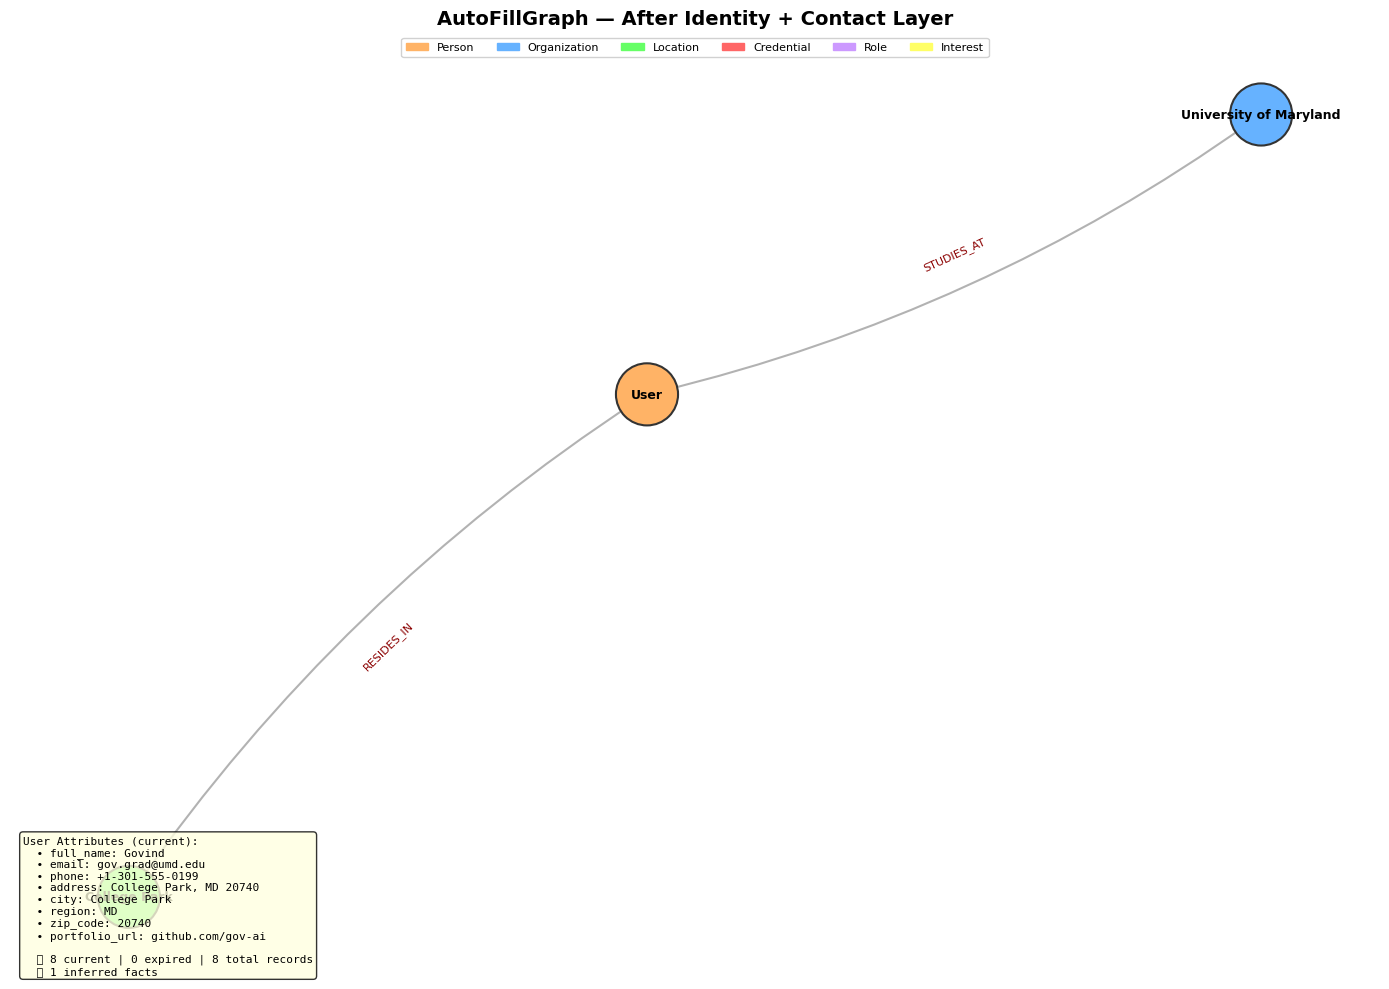


📊 System Stats:
   Entities: 3 | Relations: 2
   Facts: 8 stored | 1 inferred
   Temporal: 8 records (8 current, 0 expired)
   Fills: 0 local | 0 API-assisted
   API calls: 1


In [ ]:
###############################################################################
# ██████╗ ██╗      ██████╗  ██████╗██╗  ██╗    ██████╗
# ██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝    ╚════██╗
# ██████╔╝██║     ██║   ██║██║     █████╔╝      █████╔╝
# ██╔══██╗██║     ██║   ██║██║     ██╔═██╗     ██╔═══╝
# ██████╔╝███████╗╚██████╔╝╚██████╗██║  ██╗    ███████╗
# ╚═════╝ ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝    ╚══════╝
# LEARN: Identity + Contact Layer
###############################################################################

# @title 2. Learn: User Profile (Identity + Contact Layer)

profile_data = {
    "Full Name": "Govind",
    "Personal Email": "gov.grad@umd.edu",
    "Phone Number": "+1-301-555-0199",
    "Current Address": "College Park, MD 20740",
    "Portfolio URL": "github.com/gov-ai"
}

bot = learn_from_form(bot, profile_data, context="User Profile Setup")
bot.visualize("AutoFillGraph — After Identity + Contact Layer")
bot.print_stats()



📝 LEARNING: Academic Record

🔧 Step A: Deterministic Resolution...
   ✅ Stored: university = 'University of Maryland' [text]
   ✅ Stored: department = 'Computer Science' [text]
   ✅ Stored: degree = 'Master of Science in Machine Learning' [text]
   ✅ Stored: advisor = 'Dr. Smith' [text]
   ✅ Stored: gpa = '3.9' [numeric]
   ✅ Stored: research_interests = 'Knowledge Graphs, LLMs, Automation' [text]
   📊 Deterministic: 0 inferences

🤖 Step B: LLM Entity Extraction...
   🔗 User -[ENROLLED_IN]-> University of Maryland
   🔗 User -[BELONGS_TO_DEPARTMENT]-> Computer Science
   🔗 User -[PURSUING_DEGREE]-> Master of Science in Machine Learning
   🔗 User -[ADVISED_BY]-> Dr. Smith
   🔗 User -[RESEARCHES]-> Knowledge Graphs
   🔗 User -[RESEARCHES]-> LLMs
   🔗 User -[RESEARCHES]-> Automation
   📊 LLM: 7 entities, 7 relations

🎯 Storing interests as typed Interest entities...
   🏷️ Knowledge Graphs
   🏷️ LLMs
   🏷️ Automation


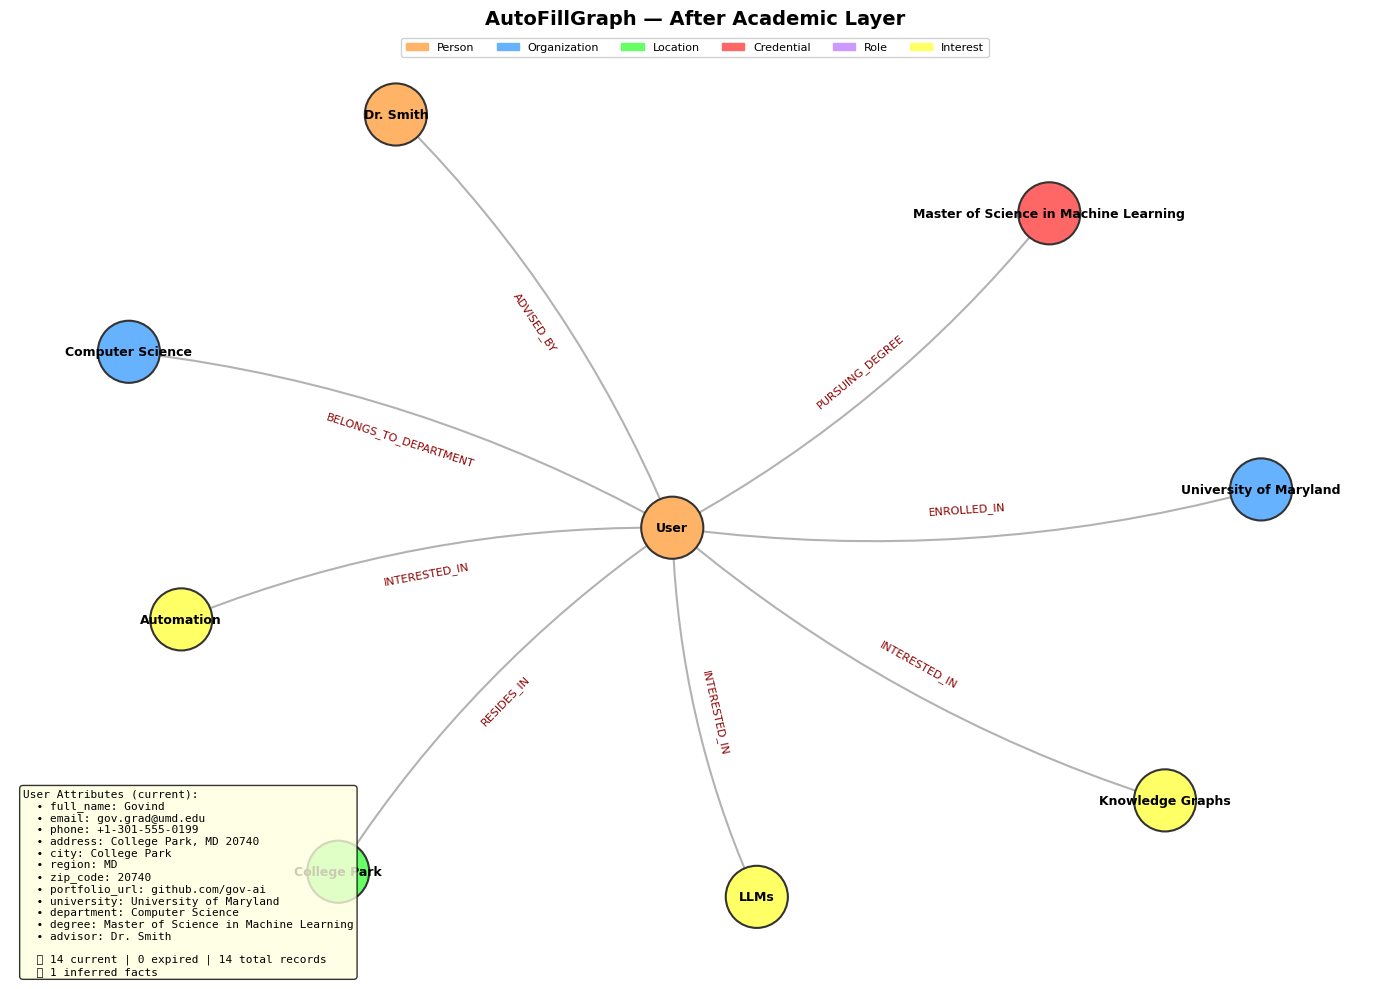


🗺️ Full Current Snapshot (public):
   full_name: Govind
   email: gov.grad@umd.edu
   phone: +1-301-555-0199
   address: College Park, MD 20740
   city: College Park
   region: MD
   zip_code: 20740
   portfolio_url: github.com/gov-ai
   university: University of Maryland
   department: Computer Science
   degree: Master of Science in Machine Learning
   advisor: Dr. Smith
   gpa: 3.9
   research_interests: Knowledge Graphs, LLMs, Automation

╔══════════════════════════════════════════════════════════╗
║  TEMPORAL TEST: Simulating Address Change                 ║
╚══════════════════════════════════════════════════════════╝

📍 Current address BEFORE update:
   College Park, MD 20740

🔄 User moves to Silver Spring...
   ⏰ Expired: address='College Park, MD 20740'
   ⏰ Expired: city='College Park'
   ⏰ Expired: zip_code='20740'

📍 Current address AFTER update:
   Silver Spring, MD 20910

📅 Temporal History — address (2 records):
   #1 ⏰ EXPIRED: 'College Park, MD 20740' [2026-03-22T19:26

In [ ]:
###############################################################################
# ██████╗ ██╗      ██████╗  ██████╗██╗  ██╗    ██████╗
# ██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝    ╚════██╗
# ██████╔╝██║     ██║   ██║██║     █████╔╝      █████╔╝
# ██╔══██╗██║     ██║   ██║██║     ██╔═██╗      ╚═══██╗
# ██████╔╝███████╗╚██████╔╝╚██████╗██║  ██╗    ██████╔╝
# ╚═════╝ ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝    ╚═════╝
# LEARN: Academic Layer + Temporal Update Test
###############################################################################

# @title 3. Learn: Academic Record + Temporal Address Change

# ─── Part A: Academic Information ─────────────────────────────────

academic_data = {
    "University Name": "University of Maryland",
    "Department": "Computer Science",
    "Degree Program": "Master of Science in Machine Learning",
    "Faculty Advisor": "Dr. Smith",
    "GPA": "3.9",
    "Research Interests": "Knowledge Graphs, LLMs, Automation"
}

bot = learn_from_form(bot, academic_data, context="Academic Record")

# Store interests as separate typed Interest entities
print("\n🎯 Storing interests as typed Interest entities...")
for interest in [i.strip() for i in
                 academic_data["Research Interests"].split(",")]:
    iid = bot._ensure_entity(interest, EntityType.INTEREST)
    bot._add_relation("user", iid, "INTERESTED_IN")
    print(f"   🏷️ {interest}")

bot.visualize("AutoFillGraph — After Academic Layer")

# Show full current snapshot
print("\n🗺️ Full Current Snapshot (public):")
for prop, val in bot.get_current_attributes("user", Sensitivity.PUBLIC).items():
    print(f"   {prop}: {val}")

# ─── Part B: Temporal Test — Address Change ───────────────────────

print("\n" + "╔" + "═"*58 + "╗")
print("║  TEMPORAL TEST: Simulating Address Change                 ║")
print("╚" + "═"*58 + "╝")

print(f"\n📍 Current address BEFORE update:")
print(f"   {bot.get_current_attributes('user').get('address', 'N/A')}")

# Simulate: user moves to Silver Spring
time.sleep(0.5)  # Visible timestamp gap
print("\n🔄 User moves to Silver Spring...")

bot._store_attribute("user", "address", "Silver Spring, MD 20910",
                     value_type="address", source="Profile Update 2025")
# Re-parse new address
new_parts = DeterministicResolvers.parse_address("Silver Spring, MD 20910")
if "city" in new_parts:
    bot._store_attribute("user", "city", new_parts["city"],
                         source="Profile Update 2025/parse")
if "zip_code" in new_parts:
    bot._store_attribute("user", "zip_code", new_parts["zip_code"],
                         source="Profile Update 2025/parse")

print(f"\n📍 Current address AFTER update:")
print(f"   {bot.get_current_attributes('user').get('address', 'N/A')}")

# Show temporal history
display_temporal_history(bot, "address")
display_temporal_history(bot, "city")

# Quick fill test — should return LATEST address
print("\n🤖 Quick test: autofilling location after update:")
quick_results = autofill_form(bot, ["Current Residency", "City"],
                               form_domain="general")
display_results(quick_results, "Temporal Fill Verification")

bot.print_stats()

In [ ]:
###############################################################################
# ██████╗ ██╗      ██████╗  ██████╗██╗  ██╗    ██╗  ██╗
# ██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝    ██║  ██║
# ██████╔╝██║     ██║   ██║██║     █████╔╝     ███████║
# ██╔══██╗██║     ██║   ██║██║     ██╔═██╗     ╚════██║
# ██████╔╝███████╗╚██████╔╝╚██████╗██║  ██╗         ██║
# ╚═════╝ ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝         ╚═╝
# AUTOFILL: Job Application + University Admission
###############################################################################

# @title 4. Autofill: Job Application + University Admission

# ─── Form A: Job Application ─────────────────────────────────────

print("╔" + "═"*58 + "╗")
print("║  FORM A: Job Application                                  ║")
print("╚" + "═"*58 + "╝")

job_fields = [
    "Candidate Name",
    "Contact Email",
    "Current Residency",
    "Degree Pursuing",
    "Tech Interests",
    "Professional Summary (Write 50 words)",
]

job_results = autofill_form(bot, job_fields, form_domain="job_application")
display_results(job_results, "Job Application — Filled")

# ─── Form B: University Admission (different labels!) ─────────────

print("\n\n" + "╔" + "═"*58 + "╗")
print("║  FORM B: University Admission                             ║")
print("╚" + "═"*58 + "╝")

admission_fields = [
    "Applicant Name",
    "Email Address",
    "Phone Number",
    "Institution",
    "Field of Study",
    "Grade Point Average",
    "Faculty Advisor",
    "Areas of Interest",
    "Country of Residence",
]

admission_results = autofill_form(bot, admission_fields,
                                   form_domain="university_admission")
display_results(admission_results, "University Admission — Filled")

# ─── Comparison: Same person, different forms ─────────────────────

print(f"\n{'═'*60}")
print(f"📊 CROSS-FORM COMPARISON")
print(f"{'═'*60}")

for name, results in [("Job App", job_results),
                       ("University", admission_results)]:
    counts = Counter(r.status.value for r in results)
    print(f"\n   {name}: " +
          ", ".join(f"{v} {k}" for k, v in counts.items()))
    local = sum(1 for r in results
                if r.status in [FillStatus.FILLED, FillStatus.INFERRED]
                and r.confidence >= 0.9)
    print(f"   High-confidence local fills: {local}/{len(results)}")

bot.print_stats()


╔══════════════════════════════════════════════════════════╗
║  FORM A: Job Application                                  ║
╚══════════════════════════════════════════════════════════╝

🤖 AUTOFILL: 6 fields (job_application)

🔧 Phase 1: Local Property Matching...
   ✅ LOCAL: 'Candidate Name' → 'Govind'
   ✅ LOCAL: 'Contact Email' → 'gov.grad@umd.edu'
   ✅ LOCAL: 'Current Residency' → 'Silver Spring, MD 20910'
   ✅ LOCAL: 'Degree Pursuing' → 'Master of Science in Machine Learning'
   ✅ LOCAL: 'Tech Interests' → 'Knowledge Graphs, LLMs, Automation'

🤖 Phase 2: LLM Fill for 1 fields...
   📦 Subgraph: 22 facts sent (of 17 total — -29% filtered)
   ✨ 'Professional Summary (Write 50 words)' → 'Govind is a Master of Science in Machine Learning graduate from the University of Maryland with a GPA of 3.9. Specializing in Knowledge Graphs, LLMs, and Automation, he is advised by Dr. Smith. Proficient in research and development, Govind leverages his expertise to drive innovation in AI-driven automa

╔══════════════════════════════════════════════════════════╗
║  STRESS TEST: 6 CAPABILITY DIMENSIONS                    ║
╚══════════════════════════════════════════════════════════╝

────────────────────────────────────────────────────────────
TEST 1: INFERENCE — Derive facts not explicitly stored
────────────────────────────────────────────────────────────

🤖 AUTOFILL: 3 fields (general)

🔧 Phase 1: Local Property Matching...
   🧠 INFERRED: 'Country of Residence' → 'United States' (rule: phone_country_code)
   ✅ LOCAL: 'University Abbreviation' → 'University of Maryland'

🤖 Phase 2: LLM Fill for 1 fields...
   📦 Subgraph: 8 facts sent (of 17 total — 53% filtered)
   ✅ 'Residency State' → 'Maryland' (filled, conf=1.0)

────────────────────────────────────────────────────────────
TEST 2: MISSING DATA — Should return UNKNOWN, not hallucinate
────────────────────────────────────────────────────────────

🤖 AUTOFILL: 4 fields (legal)

🔧 Phase 1: Local Property Matching...

🤖 Phase 2: LLM F

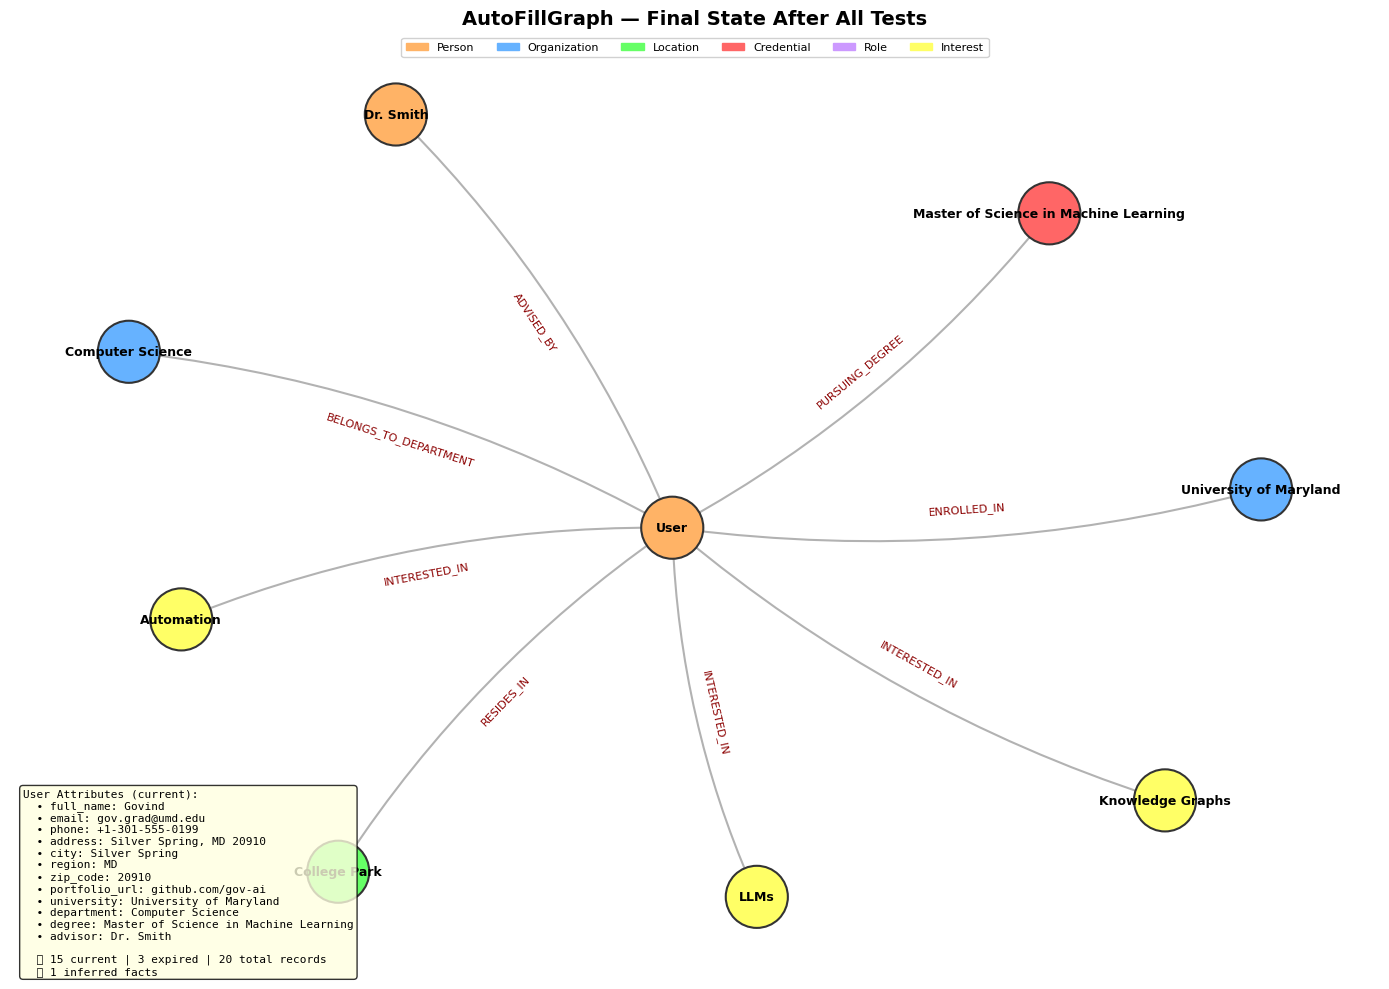

In [ ]:
###############################################################################
# ██████╗ ██╗      ██████╗  ██████╗██╗  ██╗    ███████╗
# ██╔══██╗██║     ██╔═══██╗██╔════╝██║ ██╔╝    ██╔════╝
# ██████╔╝██║     ██║   ██║██║     █████╔╝     ███████╗
# ██╔══██╗██║     ██║   ██║██║     ██╔═██╗     ╚════██║
# ██████╔╝███████╗╚██████╔╝╚██████╗██║  ██╗    ███████║
# ╚═════╝ ╚══════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝    ╚══════╝
# STRESS TEST: 6 Capability Dimensions
###############################################################################

# @title 5. Stress Test: Inference / Missing / Generative / Privacy / Temporal / Cross-Domain

print("╔" + "═"*58 + "╗")
print("║  STRESS TEST: 6 CAPABILITY DIMENSIONS                    ║")
print("╚" + "═"*58 + "╝")

# ─── TEST 1: INFERENCE ────────────────────────────────────────────

print("\n" + "─"*60)
print("TEST 1: INFERENCE — Derive facts not explicitly stored")
print("─"*60)

results_1 = autofill_form(bot, [
    "Residency State",
    "Country of Residence",
    "University Abbreviation",
], form_domain="general")

# ─── TEST 2: MISSING DATA ────────────────────────────────────────

print("\n" + "─"*60)
print("TEST 2: MISSING DATA — Should return UNKNOWN, not hallucinate")
print("─"*60)

results_2 = autofill_form(bot, [
    "Passport Number",
    "Work Experience (Years)",
    "Date of Birth",
    "Blood Type",
], form_domain="legal")

# ─── TEST 3: GENERATIVE ──────────────────────────────────────────

print("\n" + "─"*60)
print("TEST 3: GENERATIVE — Compose text from graph knowledge")
print("─"*60)

results_3 = autofill_form(bot, [
    "Professional Summary (Write 50 words)",
    "Describe your research focus (Brief)",
], form_domain="job_application")

# ─── TEST 4: PRIVACY / SENSITIVITY GATE ──────────────────────────

print("\n" + "─"*60)
print("TEST 4: PRIVACY — Sensitivity-gated subgraph retrieval")
print("─"*60)

# Store sensitive data
bot._store_attribute("user", "ssn", "123-45-6789",
                     value_type="text", source="tax_form")
bot._store_attribute("user", "passport_number", "X12345678",
                     value_type="text", source="travel_form")

for level, name in [(Sensitivity.PUBLIC, "PUBLIC"),
                    (Sensitivity.RESTRICTED, "RESTRICTED"),
                    (Sensitivity.ENCRYPTED, "ENCRYPTED")]:
    sg = bot.retrieve_subgraph(
        ["SSN", "Passport Number", "Name"], max_sens=level)
    ssn_vis = "123-45-6789" in sg
    pass_vis = "X12345678" in sg
    print(f"\n   🔐 {name} level:")
    print(f"      SSN visible:      "
          f"{'⚠️ YES' if ssn_vis else '✅ Hidden'}")
    print(f"      Passport visible: "
          f"{'⚠️ YES' if pass_vis else '✅ Hidden'}")

# ─── TEST 5: TEMPORAL — Previous address query ───────────────────

print("\n" + "─"*60)
print("TEST 5: TEMPORAL — Retrieve historical facts")
print("─"*60)

# Store an explicit previous address for temporal testing
bot._store_attribute("user", "previous_home", "Trivandrum, Kerala 695001",
                     value_type="address", source="Historical/User-provided")

results_5 = autofill_form(bot, [
    "Current Residency",
    "Previous Address",
    "Zip Code",
], form_domain="general")

# ─── TEST 6: CROSS-DOMAIN — Travel visa (wildly different labels) ─

print("\n" + "─"*60)
print("TEST 6: CROSS-DOMAIN — Travel visa form (alien labels)")
print("─"*60)

results_6 = autofill_form(bot, [
    "Legal Name",
    "Nationality",
    "Current Mailing Address",
    "Sponsoring Institution",
    "Visa Type",
], form_domain="travel_visa")
display_results(results_6, "Travel Visa Form — Filled")

# ─── COMPREHENSIVE REPORT ────────────────────────────────────────

all_results = results_1 + results_2 + results_3 + results_5 + results_6

print(f"\n{'═'*60}")
print(f"📊 COMPREHENSIVE STRESS TEST REPORT")
print(f"{'═'*60}")

counts = Counter(r.status.value for r in all_results)
print(f"\n   Fill Status Distribution:")
for status, count in counts.items():
    bar = "█" * (count * 3)
    print(f"   {status:20s} {bar} {count}")

print(f"\n   Avg Confidence by Status:")
for s in FillStatus:
    rel = [r.confidence for r in all_results if r.status == s]
    if rel:
        print(f"   {s.value:20s} {sum(rel)/len(rel):.2f} "
              f"(n={len(rel)})")

print(f"\n   Privacy Routing:")
print(f"   Local fills (no API):  {bot.stats['local_fills']}")
print(f"   API-assisted fills:    {bot.stats['api_fills']}")
print(f"   Total API calls:       {bot.stats['api_calls']}")

# Inference registry
print(f"\n🧠 Inference Registry ({len(bot.inferences)} entries):")
for inf in bot.inferences:
    print(f"   • {inf.field} = '{inf.value}' "
          f"(rule: {inf.rule}, conf: {inf.confidence})")

bot.print_stats()
bot.visualize("AutoFillGraph — Final State After All Tests")